In [1]:
ENV["PATH_LICENSE_STRING"] = "1259252040&Courtesy&&&USR&GEN2035&5_1_2026&1000&PATH&GEN&31_12_2035&0_0_0&6000&0_0"

"1259252040&Courtesy&&&USR&GEN2035&5_1_2026&1000&PATH&GEN&31_12_2035&0_0_0&6000&0_0"

In [2]:
using JuMP
using Complementarity
using LinearAlgebra
using ForwardDiff
using Plots, Plots.PlotMeasures
using Random
using Revise

In [3]:
#countries parameters
N = 3
a = [2.0, 8.0, 5.0];     
s = [0.5, 0.5, 1.0];     
b = [8.0, 7.0, 8.0];     
d = [1.0, 0.8, 1.0]; 

In [4]:
#initial tariff matrix

t_base = [0.00  0.00  0.10;
          0.00  0.00  0.10;
          0.00  0.00  0.00]

3×3 Matrix{Float64}:
 0.0  0.0  0.1
 0.0  0.0  0.1
 0.0  0.0  0.0

In [5]:
includet("functions.jl")

**Esempio 1**

In [ ]:
delta_values = 0.0:0.01:0.80
n_steps = length(delta_values)

#inizializzazione vettori
hist_q12 = zeros(n_steps)
hist_q22 = zeros(n_steps)
hist_q32 = zeros(n_steps)

hist_CS2 = zeros(n_steps)
hist_PS2 = zeros(n_steps)
hist_TR2 = zeros(n_steps)
hist_W2  = zeros(n_steps)

#ciclio di simulazione
for (iter, delta) in enumerate(delta_values)
   
    t_sim = copy(t_base)
    t_sim[1, 2] += delta 
    

    q_val, MC_val, Q_prod_val, Q_cons_val = solve_trade_model(
        t_sim, a, s, b, d
    )
    

    hist_q12[iter] = q_val[1, 2]
    hist_q22[iter] = q_val[2, 2]
    hist_q32[iter] = q_val[3, 2]
    
    CS = 0.5 * d[2] * (Q_cons_val[2]^2)
    PS = 0.5 * s[2] * (Q_prod_val[2]^2)
    
    TR = (t_sim[1, 2] * MC_val[1] * q_val[1, 2]) + 
         (t_sim[3, 2] * MC_val[3] * q_val[3, 2]) 
         
    hist_CS2[iter] = CS
    hist_PS2[iter] = PS
    hist_TR2[iter] = TR
    hist_W2[iter]  = CS + PS + TR
end

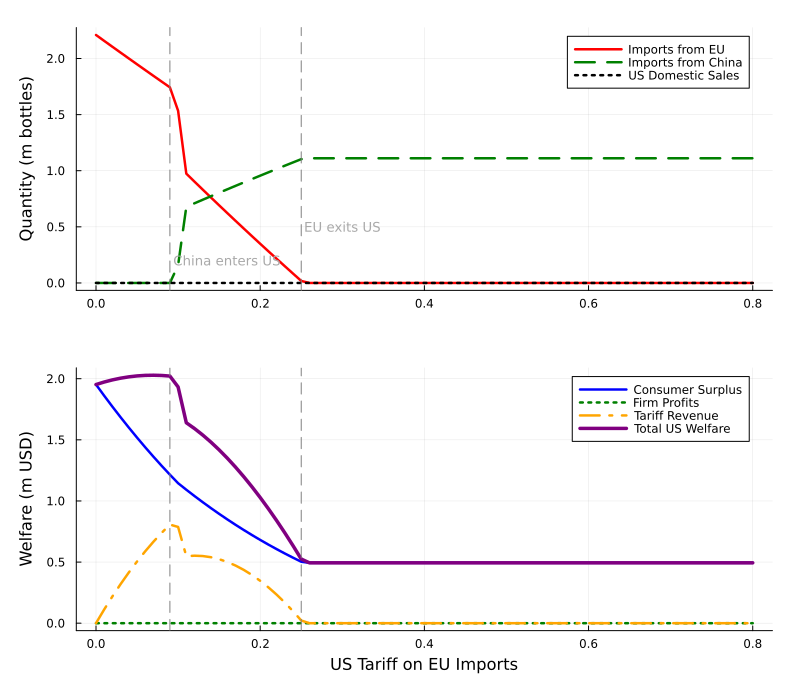

In [ ]:
# Grafico Flussi
p_flussi = plot(delta_values, hist_q12, 
    label="Imports from EU", 
    linewidth=2.5, color=:red, linestyle=:solid,
    legend=:topright, title="")
    
plot!(p_flussi, delta_values, hist_q32, 
    label="Imports from China", 
    linewidth=2.5, color=:green, linestyle=:dash)
    
plot!(p_flussi, delta_values, hist_q22, 
    label="US Domestic Sales", 
    linewidth=2.5, color=:black, linestyle=:dot)
    
ylabel!(p_flussi, "Quantity (m bottles)")

# Kink 1
vline!(p_flussi, [0.09], color=:gray, linestyle=:dash, label="")
annotate!(p_flussi, 0.095, 0.2, text("China enters US", 9, :left, :darkgray))


# Kink 3
vline!(p_flussi, [0.25], color=:gray, linestyle=:dash, label="")
annotate!(p_flussi, 0.255, 0.5, text("EU exits US", 9, :left, :darkgray))

# Grafico Welfare
p_welfare = plot(delta_values, hist_CS2, 
    label="Consumer Surplus", 
    linewidth=2.5, color=:blue, linestyle=:solid,
    legend=:topright, title="") 
    
plot!(p_welfare, delta_values, hist_PS2, 
    label="Firm Profits", 
    linewidth=2.5, color=:green, linestyle=:dot)
    
plot!(p_welfare, delta_values, hist_TR2, 
    label="Tariff Revenue", 
    linewidth=2.5, color=:orange, linestyle=:dashdot)
    
plot!(p_welfare, delta_values, hist_W2,  
    label="Total US Welfare", 
    linewidth=3.5, color=:purple, linestyle=:solid)

xlabel!(p_welfare, "US Tariff on EU Imports")
ylabel!(p_welfare, "Welfare (m USD)")

vline!(p_welfare, [0.09, 0.25], color=:gray, linestyle=:dash, label="")

plot(p_flussi, p_welfare, layout=(2,1), size=(800, 700), margin=5mm)

In [ ]:
M1 = [5.0  5.0  0.0;
      0.0  5.0  0.0;
      0.0  0.0  5.0]

M2 = [5.0  0.0  5.0;
      0.0  5.0  0.0;
      0.0  5.0  0.0]


t_singularity = [0.00  0.10  0.10;
                 0.00  0.00  0.10;
                 0.00  0.00  0.00]

q1, P1, MC1, TR1, W1 = solve_trade_model_initial_condition(M1, t_singularity, a, s, b, d)
q2, P2, MC2, TR2, W2 = solve_trade_model_initial_condition(M2, t_singularity, a, s, b, d)



println("=== CONFRONTO EQUILIBRI ALLA SINGOLARITA' (t = 10%) ===\n")

println("--- MATRICE DEI FLUSSI (q) ---")
println("Equilibrio 1 (Convergenza da M1):")
show(stdout, "text/plain", round.(q1, digits=3))
println("\n\nEquilibrio 2 (Convergenza da M2):")
show(stdout, "text/plain", round.(q2, digits=3))


println("\n--- PREZZI E COSTI GLOBALI ---")
println("Prezzi al Consumo (Eq 1): ", round.(P1, digits=3))
println("Prezzi al Consumo (Eq 2): ", round.(P2, digits=3))
println("Costi di Prod.    (Eq 1): ", round.(MC1, digits=3))
println("Costi di Prod.    (Eq 2): ", round.(MC2, digits=3))


println("\n--- WELFARE USA (Paese 2) ---")
println("Gettito Tariffario (Eq 1): \$", round(TR1, digits=4))
println("Gettito Tariffario (Eq 2): \$", round(TR2, digits=4))
println("Welfare Totale USA (Eq 1): \$", round(W1, digits=4))
println("Welfare Totale USA (Eq 2): \$", round(W2, digits=4))


=== CONFRONTO EQUILIBRI ALLA SINGOLARITA' (t = 10%) ===

--- MATRICE DEI FLUSSI (q) ---
Equilibrio 1 (Convergenza da M1):
3×3 Matrix{Float64}:
 2.867  1.692  1.707
 0.0    0.0    0.0
 0.0    0.0    0.646

Equilibrio 2 (Convergenza da M2):
3×3 Matrix{Float64}:
 2.867  1.046  2.354
 0.0    0.0    0.0
 0.0    0.646  0.0
--- PREZZI E COSTI GLOBALI ---
Prezzi al Consumo (Eq 1): [5.133, 5.646, 5.646]
Prezzi al Consumo (Eq 2): [5.133, 5.646, 5.646]
Costi di Prod.    (Eq 1): [5.133, 8.0, 5.646]
Costi di Prod.    (Eq 2): [5.133, 8.0, 5.646]

--- WELFARE USA (Paese 2) ---
Gettito Tariffario (Eq 1): $0.8685
Gettito Tariffario (Eq 2): $0.5367
Welfare Totale USA (Eq 1): $2.0137
Welfare Totale USA (Eq 2): $1.6819


**Esempio 3**

In [10]:
N = 4
a1 = [2.0, 3.0, 5.0, 4.0]
s1 = [0.5, 0.5, 1.0, 1.0]
b1 = [8.0, 7.0, 8.0, 7.0]
d1 = [1.0, 0.8, 1.0, 1.0]

#initial tariff matrix with random perturbation
Random.seed!(42) 
t_base_orig = [0.0  0.01 0.10 0.10;
               0.01 0.0  0.10 0.10;
               0.01 0.01 0.0  0.10;
               0.01 0.01 0.10 0.0 ]
t_base = copy(t_base_orig)
for i in 1:4, j in 1:4
    if i != j
        t_base[i, j] += rand() * 0.03
    end
end

In [ ]:
q_base, MC_base = solve_trade_model(t_base, a1, s1, b1, d1)

# --- 1. SCENARIO 1: PAESE 3 TASSA PAESE 1 (+1%) ---
t_scen1 = copy(t_base)
t_scen1[1, 3] += 0.01 
q_1, MC_1 = solve_trade_model(t_scen1, a1, s1, b1, d1)

# --- 2. SCENARIO 2: PAESE 4 TASSA PAESE 2 (+1%) ---
t_scen2 = copy(t_base)
t_scen2[2, 4] += 0.01
q_2, MC_2 = solve_trade_model(t_scen2, a1, s1, b1, d1)

# --- STAMPE ---
println("Matrice dei flussi di partenza")
show(stdout, "text/plain", round.(q_base, digits=3))

println("\n=== BASELINE CON RUMORE CASUALE ===")
show(stdout, "text/plain", round.(t_base, digits=3))
println("\n\nPrezzi MC Base: ", round.(MC_base, digits=4))

println("\n=== SCENARIO 1: PAESE 3 ALZA DAZIO SU PAESE 1 (+1%) ===")
println("Variazione Flussi (q_post - q_base):")
show(stdout, "text/plain", round.(q_1 .- q_base, digits=3))
println("\nVARIAZIONE MC:")
println("Paese 1 :  ", round(MC_1[1] - MC_base[1], digits=4))
println("Paese 2 :  ", round(MC_1[2] - MC_base[2], digits=4))

println("\n=== SCENARIO 2: PAESE 4 ALZA DAZIO SU PAESE 2 (+1%) ===")
println("Variazione Flussi (q_post - q_base):")
show(stdout, "text/plain", round.(q_2 .- q_base, digits=3))
println("\nVARIAZIONE MC:")
println("Paese 2 :  ", round(MC_2[2] - MC_base[2], digits=4))
println("Paese 1 :  ", round(MC_2[1] - MC_base[1], digits=4))

Matrice dei flussi di partenza
4×4 Matrix{Float64}:
 3.237  0.0    2.29   0.0
 0.0    2.831  0.102  0.536
 0.0    0.0    0.304  0.0
 0.0    0.0    0.0    1.232
=== BASELINE CON RUMORE CASUALE ===
4×4 Matrix{Float64}:
 0.0    0.029  0.114  0.114
 0.031  0.0    0.12   0.105
 0.028  0.03   0.0    0.114
 0.019  0.03   0.119  0.0

Prezzi MC Base: [4.7633, 4.7349, 5.304, 5.2319]

=== SCENARIO 1: PAESE 3 ALZA DAZIO SU PAESE 1 (+1%) ===
Variazione Flussi (q_post - q_base):
4×4 Matrix{Float64}:
 0.031   0.0    -0.092   0.0
 0.0    -0.015   0.065  -0.026
 0.0     0.0     0.013   0.0
 0.0     0.0     0.0     0.013
VARIAZIONE MC:
Paese 1 (Bersaglio):  -0.0305
Paese 2 (Sostituto):  0.0119

=== SCENARIO 2: PAESE 4 ALZA DAZIO SU PAESE 2 (+1%) ===
Variazione Flussi (q_post - q_base):
4×4 Matrix{Float64}:
 0.009  0.0    -0.027   0.0
 0.0    0.011   0.046  -0.075
 0.0    0.0    -0.01    0.0
 0.0    0.0     0.0     0.038
VARIAZIONE MC:
Paese 2 (Bersaglio):  -0.0088
Paese 1 (Sostituto):  -0.0089
